#**FocusGuard - A Multimodal Distraction Detection System for Productivity Monitoring**

## **Screen Detection Component: Resnet18 + Custom Dataset (4000+ screenshots)**





In this notebook i will train RESNET18 for screenshoot classification using my custom datasets.



In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU found')

2.6.0+cu124
True
NVIDIA GeForce RTX 2070


In [ ]:
import torch.multiprocessing as mp
try:
    mp.set_start_method('spawn', force=True)
except RuntimeError:
    pass

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import torchvision.models as models
import shutil
import os
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torch.utils.data import DataLoader, random_split, Subset
from sklearn.model_selection import train_test_split

In [ ]:
# Force device to CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if not torch.cuda.is_available():
    print('Warning: CUDA not available, falling back to CPU.')
else:
    print(f'Using device: {device}')

Using device: cuda


In [ ]:
# ==========================================
# GLOBAL HYPERPARAMETERS & CONFIG
# ==========================================

# Dataset Config
NUM_CLASSES = 4
data_dir = r'C:\Users\angel\PycharmProjects\FocusGuard\data'

# Training Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MOMENTUM = 0.9
NUM_EPOCHS = 8
DROPOUT_RATE = 0.5

# Hardware Config
NUM_WORKERS = 4
PIN_MEMORY = True

print("Global hyperparameters initialized.")

Global hyperparameters initialized.


In [ ]:
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# Training transform with augmentation to improve generalization due to my limited Dataset
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(degrees=10),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Val/test transform - no augmentation, only resize and normalize
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## Data Preprocessing & Exploration

### **I.A Screen Classifier: Data Loading and Stratification**

In [ ]:
from collections import Counter

if os.path.exists(data_dir):
    # Load full dataset with val/test transform as default
    full_dataset = ImageFolder(data_dir, transform=val_test_transform)
    labels = [label for _, label in full_dataset.samples]

    # Count images per class
    class_counts = Counter(labels)
    class_names = full_dataset.classes

    # Stratified split to preserve class balance across all three sets
    indices = list(range(len(full_dataset)))
    train_idx, temp_idx, _, temp_labels = train_test_split(
        indices, labels, test_size=0.2, stratify=labels, random_state=42
    )
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.5, stratify=temp_labels, random_state=42
    )

    # Apply augmentation only to train subset
    train_dataset = Subset(ImageFolder(data_dir, transform=train_transform), train_idx)
    val_dataset   = Subset(full_dataset, val_idx)
    test_dataset  = Subset(full_dataset, test_idx)

    print(f'Local dataset loaded from: {data_dir}')
    print(f'Total images : {len(full_dataset)}')
    print('-' * 30)
    print('Class Distribution:')
    for idx, name in enumerate(class_names):
        print(f'  {name:<12}: {class_counts[idx]} images')
    print('-' * 30)
    print(f'Train set    : {len(train_dataset)} images')
    print(f'Val set      : {len(val_dataset)} images')
    print(f'Test set     : {len(test_dataset)} images')

    # Display first 5 samples to confirm mapping
    print('\nSample Label Mapping (first 5 samples):')
    for i in range(5):
        path, label = full_dataset.samples[i]
        print(f'  {os.path.basename(path)} -> {class_names[label]}')
else:
    print(f'Error: Local dataset path not found at {data_dir}. Please ensure the data folder exists.')

Local dataset loaded from: C:\Users\angel\PycharmProjects\FocusGuard\data
Total images : 4076
------------------------------
Class Distribution:
  Gaming      : 1022 images
  Productive  : 1042 images
  Twitch      : 1000 images
  YouTube     : 1012 images
------------------------------
Train set    : 3260 images
Val set      : 408 images
Test set     : 408 images

Sample Label Mapping (first 5 samples):
  Gaming_20260416_211926_00000.png -> Gaming
  Gaming_20260416_211930_00001.png -> Gaming
  Gaming_20260416_211933_00002.png -> Gaming
  Gaming_20260416_211936_00003.png -> Gaming
  Gaming_20260416_211939_00004.png -> Gaming


In [ ]:
# Create DataLoaders using global config
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f'DataLoaders ready | Batch size: {BATCH_SIZE}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

DataLoaders ready | Batch size: 64
Train batches: 51 | Val batches: 7 | Test batches: 7


# The Two-Phase Strategy

To train the model effectively, I implemented a two-phase strategy. First, I **froze** the entire convolutional base and trained only the new classification layer, which allowed it to safely align with the pre-trained features. Then, in the second phase, I **unfroze** the top layers, like layer4, and significantly reduced the learning rate. This allowed me to gently fine-tune the model to recognize my specific visual cues, like a Twitch interface, without destroying the foundational edge detectors.

### **I.B Screen Classifier: Training Function Implementation**

In [ ]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs):

    """
    1. Description:
    Executes training and validation loops. It unfreezes 'layer4' at epoch 5 and divides the learning rate by 10 for robust fine-tuning.

    2. Input Arguments:
        model (torch.nn.Module): The neural network to train.
        train_loader (DataLoader): Training data batches.
        val_loader (DataLoader): Validation data batches.
        criterion (callable): Loss function.
        optimizer (torch.optim.Optimizer): Optimization algorithm.
        num_epochs (int): Total number of epochs.

    3. Output Arguments:
        history (dict): Contains lists of floats for 'train_loss', 'val_loss', 'train_acc', and 'val_acc'.

    4. Example:
        history = train(model, train_loader, val_loader, criterion, optimizer, num_epochs=10)
    """

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    # Get dataset sizes from loaders to avoid relying on globals
    num_train = len(train_loader.dataset)
    num_val = len(val_loader.dataset)

    for epoch in range(num_epochs):

        # Unfreeze layer4 at epoch 5
        if epoch == 5:
            print("Unfreezing layer4...")
            for param in model.layer4.parameters():
                param.requires_grad = True

            # AdamW optimizer with new trainable params
            # Reduce the base learning rate by 10 for fine-tuning
            current_lr = optimizer.param_groups[0]['lr']
            current_wd = optimizer.param_groups[0]['weight_decay']

            optimizer = torch.optim.AdamW(
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=current_lr / 10,
                weight_decay=current_wd
            )

        print(f'\n{"="*60}')
        print(f'EPOCH [{epoch+1}/{num_epochs}]')
        print(f'{"="*60}')

        model.train()

        running_loss = 0.0
        running_corrects = 0

        for i, (inputs, labels) in enumerate(train_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            if (i + 1) % 10 == 0:
                batch_acc = running_corrects.float() / ((i + 1) * train_loader.batch_size)
                print(f'  Epoch [{epoch+1}/{num_epochs}] | Batch [{i+1}/{len(train_loader)}] | Loss: {loss.item():.4f} | Acc: {batch_acc:.4f}')

        train_loss = running_loss / num_train
        train_acc = running_corrects.float() / num_train

        model.eval()

        running_loss = 0.0
        running_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

        val_loss = running_loss / num_val
        val_acc = running_corrects.float() / num_val

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc.item())
        history['val_acc'].append(val_acc.item())

        print(f'\n--- Epoch [{epoch+1}/{num_epochs}] Summary ---')
        print(f'  Train Loss : {train_loss:.4f} | Train Acc : {train_acc:.4f}')
        print(f'  Val Loss   : {val_loss:.4f} | Val Acc   : {val_acc:.4f}')
        print(f'  Overfit Gap (val - train loss): {val_loss - train_loss:.4f}')

    return history

### **I.C Screen Classifier: Model Initialization and Training Execution**

Training on: cuda
Model device: cuda:0

EPOCH [1/8]
  Epoch [1/8] | Batch [10/51] | Loss: 1.3922 | Acc: 0.2906
  Epoch [1/8] | Batch [20/51] | Loss: 1.1173 | Acc: 0.3477
  Epoch [1/8] | Batch [30/51] | Loss: 1.0428 | Acc: 0.4135
  Epoch [1/8] | Batch [40/51] | Loss: 0.7579 | Acc: 0.4680
  Epoch [1/8] | Batch [50/51] | Loss: 0.8523 | Acc: 0.5100

--- Epoch [1/8] Summary ---
  Train Loss : 1.1335 | Train Acc : 0.5132
  Val Loss   : 0.6739 | Val Acc   : 0.7745
  Overfit Gap (val - train loss): -0.4596

EPOCH [2/8]
  Epoch [2/8] | Batch [10/51] | Loss: 0.8824 | Acc: 0.7000
  Epoch [2/8] | Batch [20/51] | Loss: 0.5437 | Acc: 0.7117
  Epoch [2/8] | Batch [30/51] | Loss: 0.6908 | Acc: 0.7234
  Epoch [2/8] | Batch [40/51] | Loss: 0.7459 | Acc: 0.7273
  Epoch [2/8] | Batch [50/51] | Loss: 0.4924 | Acc: 0.7341

--- Epoch [2/8] Summary ---
  Train Loss : 0.6969 | Train Acc : 0.7350
  Val Loss   : 0.4316 | Val Acc   : 0.9093
  Overfit Gap (val - train loss): -0.2653

EPOCH [3/8]
  Epoch [3/8] | Ba

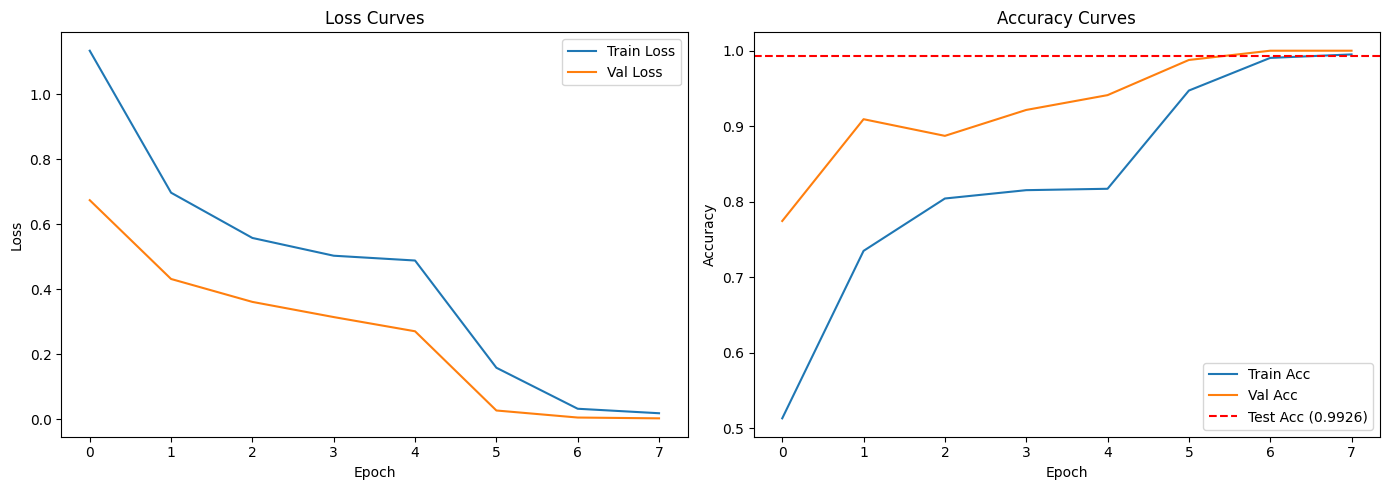

In [ ]:
# Load the pre-trained ResNet-18 model
# Pretrained ResNet18 weights from:
# He, K., et al. (2016). Deep Residual Learning for Image Recognition. CVPR.
# Weights source: torchvision.models (IMAGENET1K_V1)
# ImageNet dataset: Deng, J., et al. (2009). ImageNet: A Large-Scale Hierarchical Image Database. CVPR.
model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Then replace with dropout + linear
in_features = model.fc.in_features
model.fc = torch.nn.Sequential(
    torch.nn.Dropout(p=DROPOUT_RATE),
    torch.nn.Linear(in_features, NUM_CLASSES)
)

# Ensure fc is trainable
for param in model.fc.parameters():
    param.requires_grad = True

# Move model to device and start training
model = model.to(device)

# Define loss and optimizer using global config
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.fc.parameters(),   # ONLY fc trains initially
    lr=LEARNING_RATE,
    # momentum=MOMENTUM,     # ONLY for SDG
    weight_decay=WEIGHT_DECAY
)

# Confirm device before training
print(f'Training on: {device}')
print(f'Model device: {next(model.parameters()).device}')

# Start training
history = train(model, train_loader, val_loader, criterion, optimizer, num_epochs=NUM_EPOCHS)

# Evaluate final model performance on the test set
# Test evaluation is done only once after training to avoid data leakage
model.eval()
test_corrects = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_corrects += torch.sum(preds == labels.data)
test_acc = test_corrects.float() / len(test_dataset)

# Print final summary metrics across all three splits
print("\n" + "="*30)
print(f"Final Training Accuracy:   {history['train_acc'][-1]:.4f}")
print(f"Final Validation Accuracy: {history['val_acc'][-1]:.4f}")
print(f"Final Test Accuracy:       {test_acc:.4f}")
print("="*30 + "\n")

# Plot loss and accuracy curves to visualize training behavior
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves - a large gap between train and val indicates overfitting
ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'],   label='Val Loss')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy curves - add a horizontal line for final test accuracy as reference
ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['val_acc'],   label='Val Acc')
ax2.axhline(y=test_acc.item(), color='r', linestyle='--', label=f'Test Acc ({test_acc:.4f})')
ax2.set_title('Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# import torch

# # 1. Save the model state dictionary
# model_filename = 'resnet18_screen_AdamW_model.pth'
# torch.save(model.state_dict(), model_filename)

# print(f'Model successfully saved locally as: {model_filename}')
# print(f'Location: {os.path.abspath(model_filename)}')

### **I.D Screen Classifier: Quantitative & Qualitative Evaluation**

Overall Accuracy: 0.9926

Detailed Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

      Gaming       0.99      0.99      0.99       102
  Productive       1.00      1.00      1.00       105
      Twitch       0.98      0.99      0.99       100
     YouTube       1.00      0.99      1.00       101

    accuracy                           0.99       408
   macro avg       0.99      0.99      0.99       408
weighted avg       0.99      0.99      0.99       408



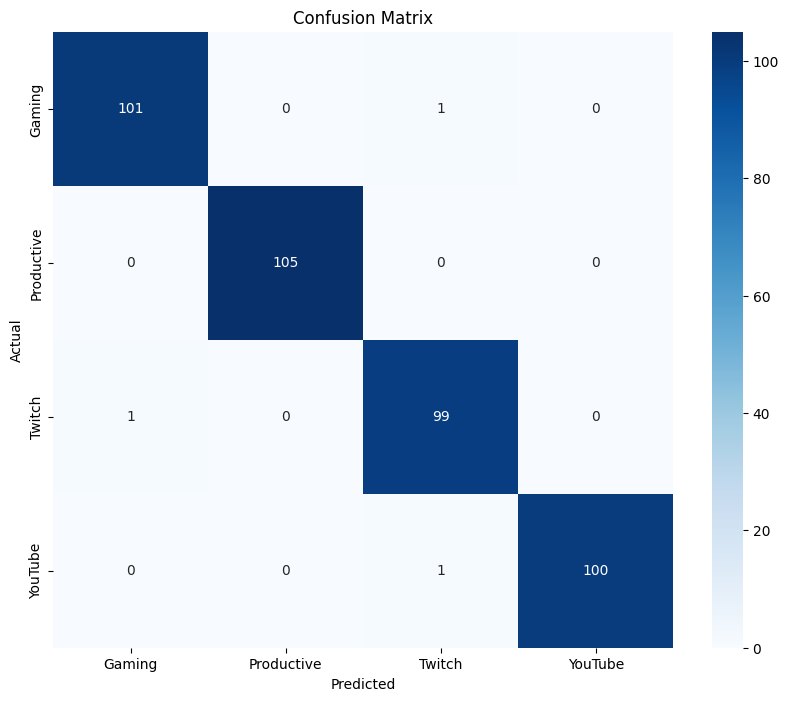

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

def comprehensive_evaluation(model, test_loader, device):
    """
    1. Description:
    Performs a single inference pass to evaluate the model. It calculates overall accuracy, prints a classification report, and displays a confusion matrix plot.

    2. Input Arguments:
        model (torch.nn.Module): The trained neural network to evaluate.
        test_loader (DataLoader): The DataLoader containing the test dataset.
        device (torch.device or str): The hardware device for computation ('cuda' or 'cpu').

    3. Output Arguments:
        None (Outputs are printed to the console and plotted visually).

    4. Example:
        comprehensive_evaluation(model, test_loader, device='cuda')
    """
    model.eval()
    all_labels = []
    all_preds = []
    classes = test_loader.dataset.dataset.classes

    # 1. Single Inference Pass
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    # 2. Compute and Print Metrics in text format
    overall_accuracy = accuracy_score(all_labels, all_preds)
    print(f"Overall Accuracy: {overall_accuracy:.4f}")
    print("\nDetailed Classification Report:")
    print("-" * 53)
    # This generates the text format table for precision, recall, f1, and support
    print(classification_report(all_labels, all_preds, target_names=classes))

    # 3. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Run the consolidated evaluation
comprehensive_evaluation(model, test_loader, device)

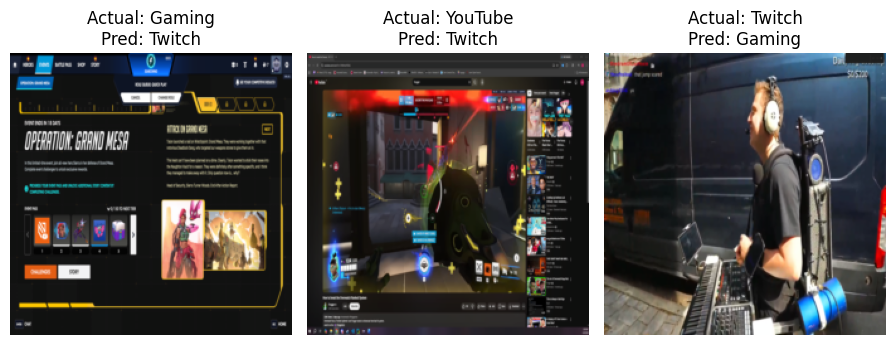

In [ ]:
def visualize_misclassified(model, test_loader, device, num_images=5):
    """
    1. Description:
    Finds and plots a specified number of misclassified images. It unnormalizes the image tensors and visually displays the actual versus predicted labels to help debug model errors.

    2. Input Arguments:
        model (torch.nn.Module): The trained neural network.
        test_loader (DataLoader): The test dataset batches.
        device (torch.device or str): Hardware for computation ('cuda' or 'cpu').
        num_images (int, optional): Maximum number of misclassified images to display. Defaults to 5.

    3. Output Arguments:
        None (Outputs a matplotlib visual grid of images).

    4. Example:
        visualize_misclassified(model, test_loader, device='cuda', num_images=5)
    """
    model.eval()
    misclassified_images = []
    actual_labels = []
    pred_labels = []
    classes = test_loader.dataset.dataset.classes

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for i in range(len(preds)):
                if preds[i] != labels[i]:
                    misclassified_images.append(inputs[i].cpu())
                    actual_labels.append(classes[labels[i]])
                    pred_labels.append(classes[preds[i]])
                if len(misclassified_images) >= num_images:
                    break
            if len(misclassified_images) >= num_images:
                break

    plt.figure(figsize=(15, 5))
    for i in range(len(misclassified_images)):
        plt.subplot(1, num_images, i + 1)
        img = misclassified_images[i].numpy().transpose((1, 2, 0))
        # Unnormalize
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.title(f'Actual: {actual_labels[i]}\nPred: {pred_labels[i]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_misclassified(model, test_loader, device)

In [ ]:
!pip install torchinfo

from torchinfo import summary

# Provide a summary of the model structure and parameter counts
summary(model, input_size=(1, 3, 224, 224), device=device.type)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 4]                    --
├─Conv2d: 1-1                            [1, 64, 112, 112]         (9,408)
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         (128)
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           (36,864)
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           (128)
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           (36,864)
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           (128)
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]   

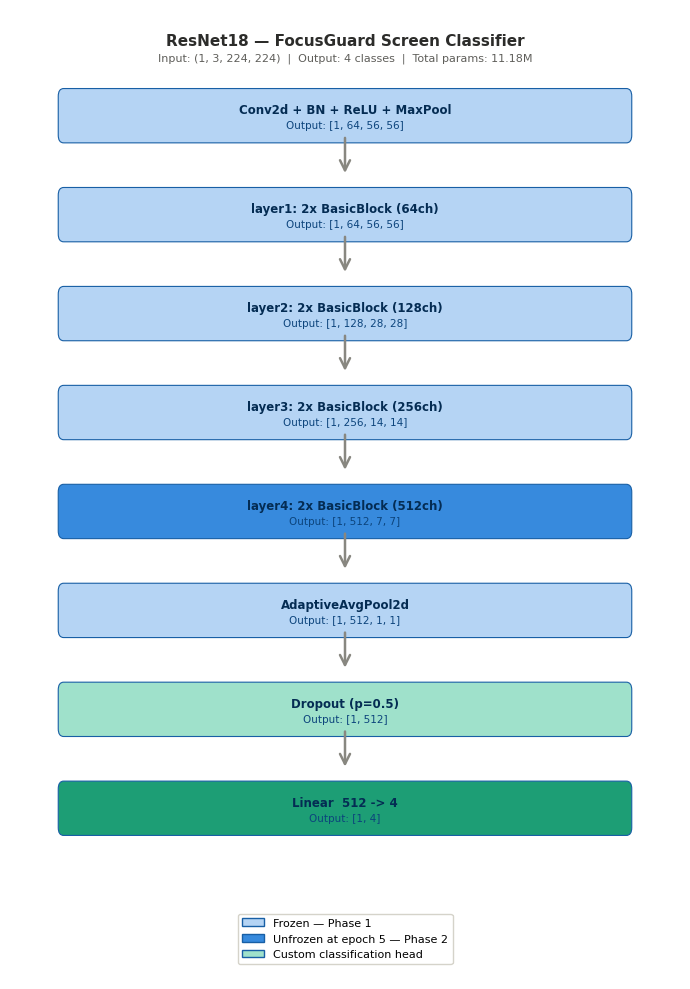

Saved: resnet18_architecture.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Architecture layers derived from torchinfo summary output
layers = [
    ('Conv2d + BN + ReLU + MaxPool',  '[1, 64, 56, 56]',   '#B5D4F4', 'Frozen'),
    ('layer1: 2x BasicBlock (64ch)',   '[1, 64, 56, 56]',   '#B5D4F4', 'Frozen'),
    ('layer2: 2x BasicBlock (128ch)',  '[1, 128, 28, 28]',  '#B5D4F4', 'Frozen'),
    ('layer3: 2x BasicBlock (256ch)',  '[1, 256, 14, 14]',  '#B5D4F4', 'Frozen'),
    ('layer4: 2x BasicBlock (512ch)',  '[1, 512, 7, 7]',    '#378ADD', 'Unfrozen at epoch 5'),
    ('AdaptiveAvgPool2d',              '[1, 512, 1, 1]',    '#B5D4F4', 'Frozen'),
    ('Dropout (p=0.5)',                '[1, 512]',          '#9FE1CB', 'Custom head'),
    ('Linear  512 -> 4',               '[1, 4]',            '#1D9E75', 'Custom head'),
]

fig, ax = plt.subplots(figsize=(7, 10))
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.text(0.5, 0.975, 'ResNet18 — FocusGuard Screen Classifier',
        ha='center', va='top', fontsize=11, fontweight='bold', color='#2C2C2A')
ax.text(0.5, 0.955, 'Input: (1, 3, 224, 224)  |  Output: 4 classes  |  Total params: 11.18M',
        ha='center', va='top', fontsize=8, color='#5F5E5A')

box_h   = 0.04    # smaller boxes
gap     = 0.02
arrow_h = 0.042   # larger arrows
start_y = 0.91

for i, (name, shape, color, phase) in enumerate(layers):
    y_top = start_y - i * (box_h + gap + arrow_h)
    y_box = y_top - box_h

    # Draw box
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.08, y_box), 0.84, box_h,
        boxstyle='round,pad=0.008',
        facecolor=color, edgecolor='#185FA5', linewidth=0.8
    ))

    # Layer name
    ax.text(0.50, y_box + box_h * 0.65, name,
            ha='center', va='center', fontsize=8.5,
            fontweight='bold', color='#042C53')

    # Output shape
    ax.text(0.50, y_box + box_h * 0.25, f'Output: {shape}',
            ha='center', va='center', fontsize=7.5, color='#0C447C')

    # Draw arrow down (except after last box)
    if i < len(layers) - 1:
        arrow_top = y_box
        arrow_bot = arrow_top - arrow_h
        ax.annotate('', xy=(0.5, arrow_bot), xytext=(0.5, arrow_top),
                    arrowprops=dict(arrowstyle='->', color='#888780', lw=1.8,
                                   mutation_scale=18))

# Legend
frozen_p   = mpatches.Patch(facecolor='#B5D4F4', edgecolor='#185FA5', label='Frozen — Phase 1')
unfrozen_p = mpatches.Patch(facecolor='#378ADD', edgecolor='#185FA5', label='Unfrozen at epoch 5 — Phase 2')
custom_p   = mpatches.Patch(facecolor='#9FE1CB', edgecolor='#185FA5', label='Custom classification head')
ax.legend(handles=[frozen_p, unfrozen_p, custom_p],
          loc='lower center', fontsize=8, framealpha=0.95,
          edgecolor='#D3D1C7', bbox_to_anchor=(0.5, 0.01))

plt.tight_layout()
plt.savefig('resnet18_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: resnet18_architecture.png')

### PEP8 Compliance

In [5]:
!pip install nbqa autopep8
!nbqa autopep8 --in-place FocusGuard_ScreenClassifier.ipynb

No such file or directory: FocusGuard_ScreenClassifier.ipynb
